# Análisis Exploratorio de Datos (EDA): Aprobación de Créditos

**Proyecto Final - MLOps**  
**Universidad de Medellín · Docente: David Palacio Jimenez**  
**Equipo 8:** Atehortua Arango Mateo · Avila Pinto Cristian Camilo · Barrera Camargo Paula Carolina

---

## Objetivo

Predecir si un solicitante de crédito será aprobado o rechazado en función de sus características financieras y personales. Este EDA busca comprender la estructura de los datos, identificar patrones y definir decisiones de preprocesamiento antes de construir el pipeline de MLOps.

### Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `loan_id` | ID | Identificador único  |
| `no_of_dependents` | Numérica | Número de personas a cargo |
| `education` | Categórica | Nivel educativo (Graduate / Not Graduate) |
| `self_employed` | Categórica | Trabaja de forma independiente (Yes / No) |
| `income_annum` | Numérica | Ingreso anual |
| `loan_amount` | Numérica | Monto del préstamo solicitado |
| `loan_term` | Numérica | Plazo del préstamo (en años) |
| `cibil_score` | Numérica | Puntaje crediticio (300-900) |
| `residential_assets_value` | Numérica | Valor activos residenciales |
| `commercial_assets_value` | Numérica | Valor activos comerciales |
| `luxury_assets_value` | Numérica | Valor activos de lujo |
| `bank_asset_value` | Numérica | Valor activos bancarios |
| `loan_status` | **Target** | Resultado del crédito (Approved / Rejected) |

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)



## 2. Carga y Vista General de los Datos

In [2]:
DATA_PATH = Path('../data/loan_approval_dataset.csv')

df = pd.read_csv(DATA_PATH)

# Limpiar espacios en nombres de columnas
df.columns = [c.strip() for c in df.columns]

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

Dataset cargado: 4269 filas × 13 columnas


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.describe(include='all')

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


In [5]:
print('Tipos de variables:')
print(df.dtypes)
print('\nValores únicos por columna:')
print(df.nunique())

Tipos de variables:
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Valores únicos por columna:
loan_id                     4269
no_of_dependents               6
education                      2
self_employed                  2
income_annum                  98
loan_amount                  378
loan_term                     10
cibil_score                  601
residential_assets_value     278
commercial_assets_value      188
luxury_assets_value          379
bank_asset_value             146
loan_status                    2
dtype: int64


## 3. Limpieza de Datos

In [7]:
# 3.1 Valores nulos
print(' Valores nulos por columna')
nulls = df.isnull().sum()
print(nulls)
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')

 Valores nulos por columna
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Total de filas con al menos un nulo: 0


In [8]:
# 3.2 Duplicados
print(f'Filas duplicadas: {df.duplicated().sum()}')

Filas duplicadas: 0


In [10]:
# 3.3 Valores negativos en variables de activos
asset_cols = ['residential_assets_value', 'commercial_assets_value',
              'luxury_assets_value', 'bank_asset_value', 'income_annum', 'loan_amount']

print(' Valores negativos por columna')
for col in asset_cols:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f'  {col}: {neg} filas con valores negativos')
    else:
        print(f'  {col}: sin valores negativos ')

 Valores negativos por columna
  residential_assets_value: 28 filas con valores negativos
  commercial_assets_value: sin valores negativos 
  luxury_assets_value: sin valores negativos 
  bank_asset_value: sin valores negativos 
  income_annum: sin valores negativos 
  loan_amount: sin valores negativos 


In [11]:
# Detalle de las filas con residential_assets_value negativo
df_neg = df[df['residential_assets_value'] < 0]
print(f'Filas con residential_assets_value negativo: {len(df_neg)}')
df_neg[['loan_id', 'loan_status', 'residential_assets_value']].head(10)

Filas con residential_assets_value negativo: 28


,loan_id,loan_status,residential_assets_value
59,60,Approved,-100000
196,197,Approved,-100000
559,560,Rejected,-100000
702,703,Approved,-100000
737,738,Rejected,-100000
784,785,Approved,-100000
904,905,Approved,-100000
1089,1090,Rejected,-100000
1163,1164,Approved,-100000
1350,1351,Rejected,-100000


### Observaciones sobre calidad de datos

-  No se encontraron valores nulos en ninguna columna. El dataset está completo.
-  No hay registros duplicados.
-  Se detectaron 28 filas con `residential_assets_value` negativo. Este es un error de captura, ya que el valor de un activo no puede ser negativo. Se decidirá en el pipeline de preprocesamiento si reemplazarlos por 0 o tratarlos como valores atípicos.
- **`loan_id`:** Es un identificador único sin valor predictivo

## 4. Análisis de la Variable Objetivo (`loan_status`)

In [12]:
# Distribución del target
target_counts = df['loan_status'].value_counts()
target_pct = df['loan_status'].value_counts(normalize=True) * 100

fig = px.bar(
    x=target_counts.index,
    y=target_counts.values,
    color=target_counts.index,
    color_discrete_map={'Approved': '#2ecc71', 'Rejected': '#e74c3c'},
    title='Distribución de la Variable Objetivo: loan_status',
    labels={'x': 'Estado del Crédito', 'y': 'Cantidad de Solicitudes'},
    text=target_counts.values
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

print('\nDistribución del target:')
for label, count, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    print(f'  {label}: {count} registros ({pct:.1f}%)')


Distribución del target:
   Approved: 2656 registros (62.2%)
   Rejected: 1613 registros (37.8%)


### Observaciones sobre el target

- **Approved:** 2,656 solicitudes (62.2%)
- **Rejected:** 1,613 solicitudes (37.8%)

Existe un desbalance de aproximadamente 62%/38%.

## 5. Análisis Univariado

### 5.1 Variables Numéricas

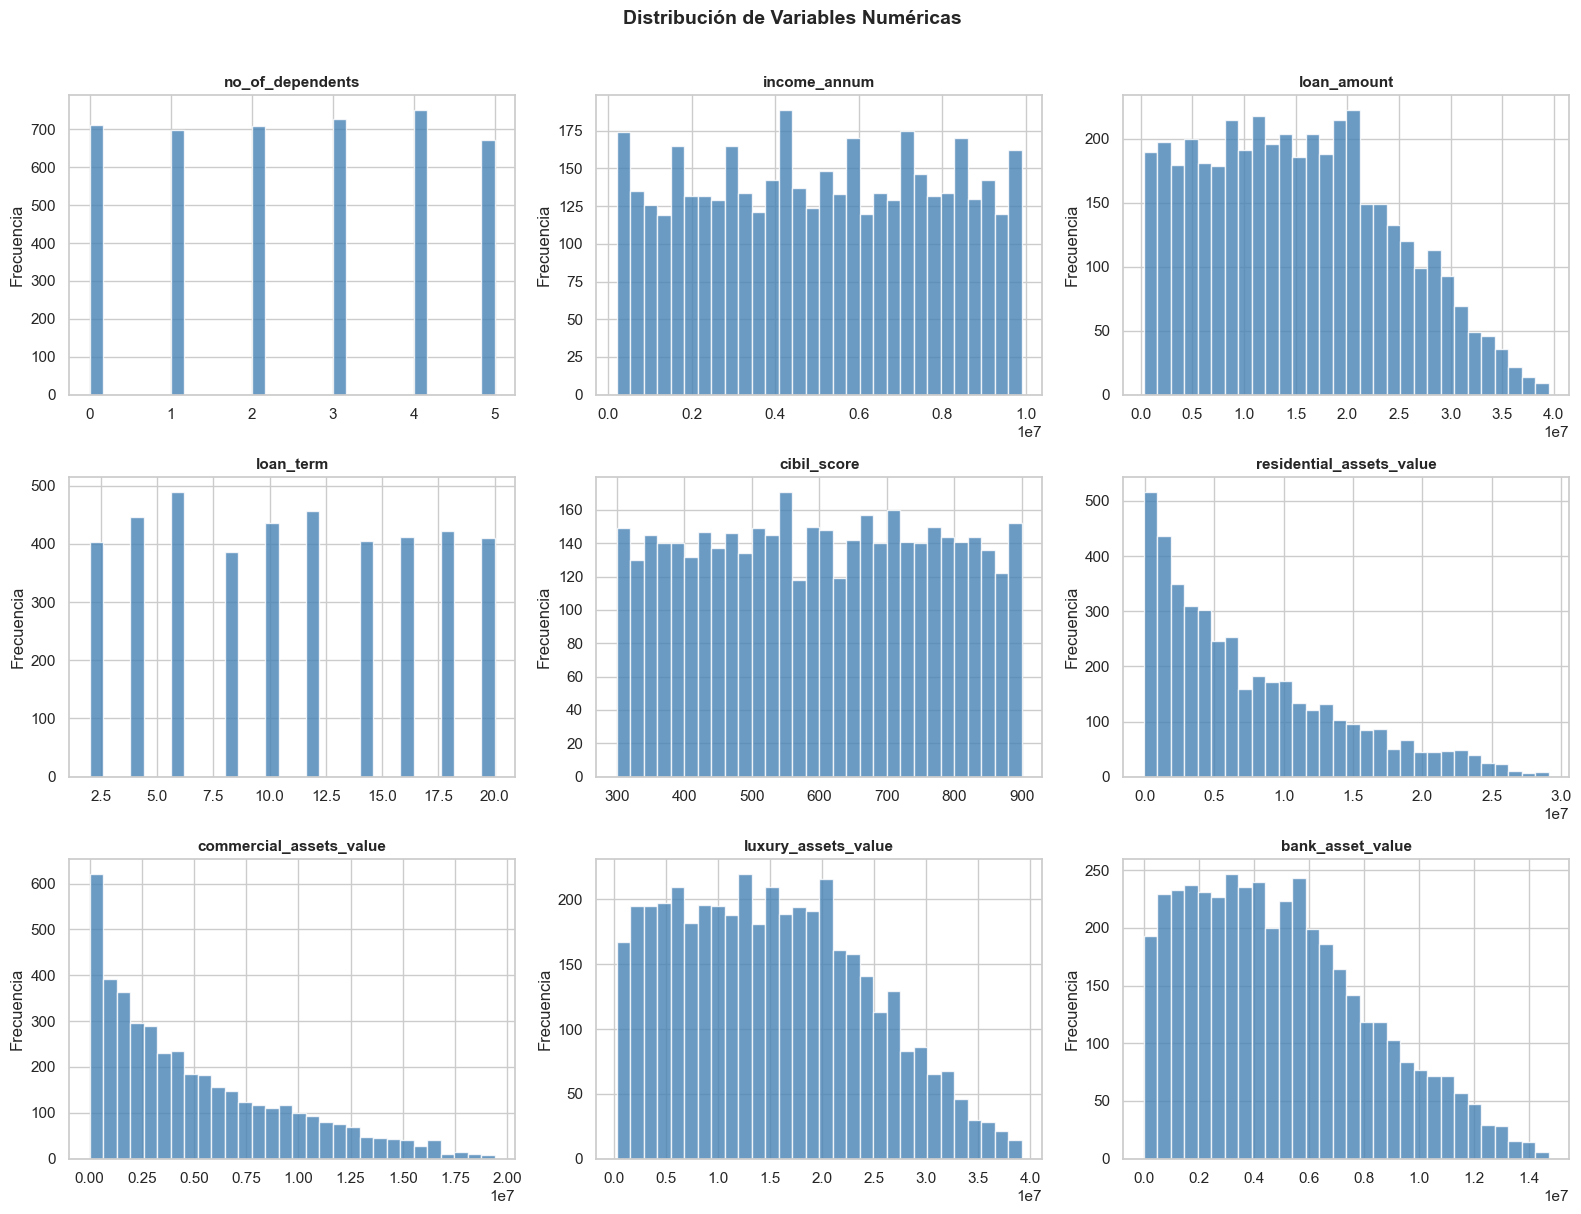

In [13]:
numeric_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
                'cibil_score', 'residential_assets_value', 'commercial_assets_value',
                'luxury_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

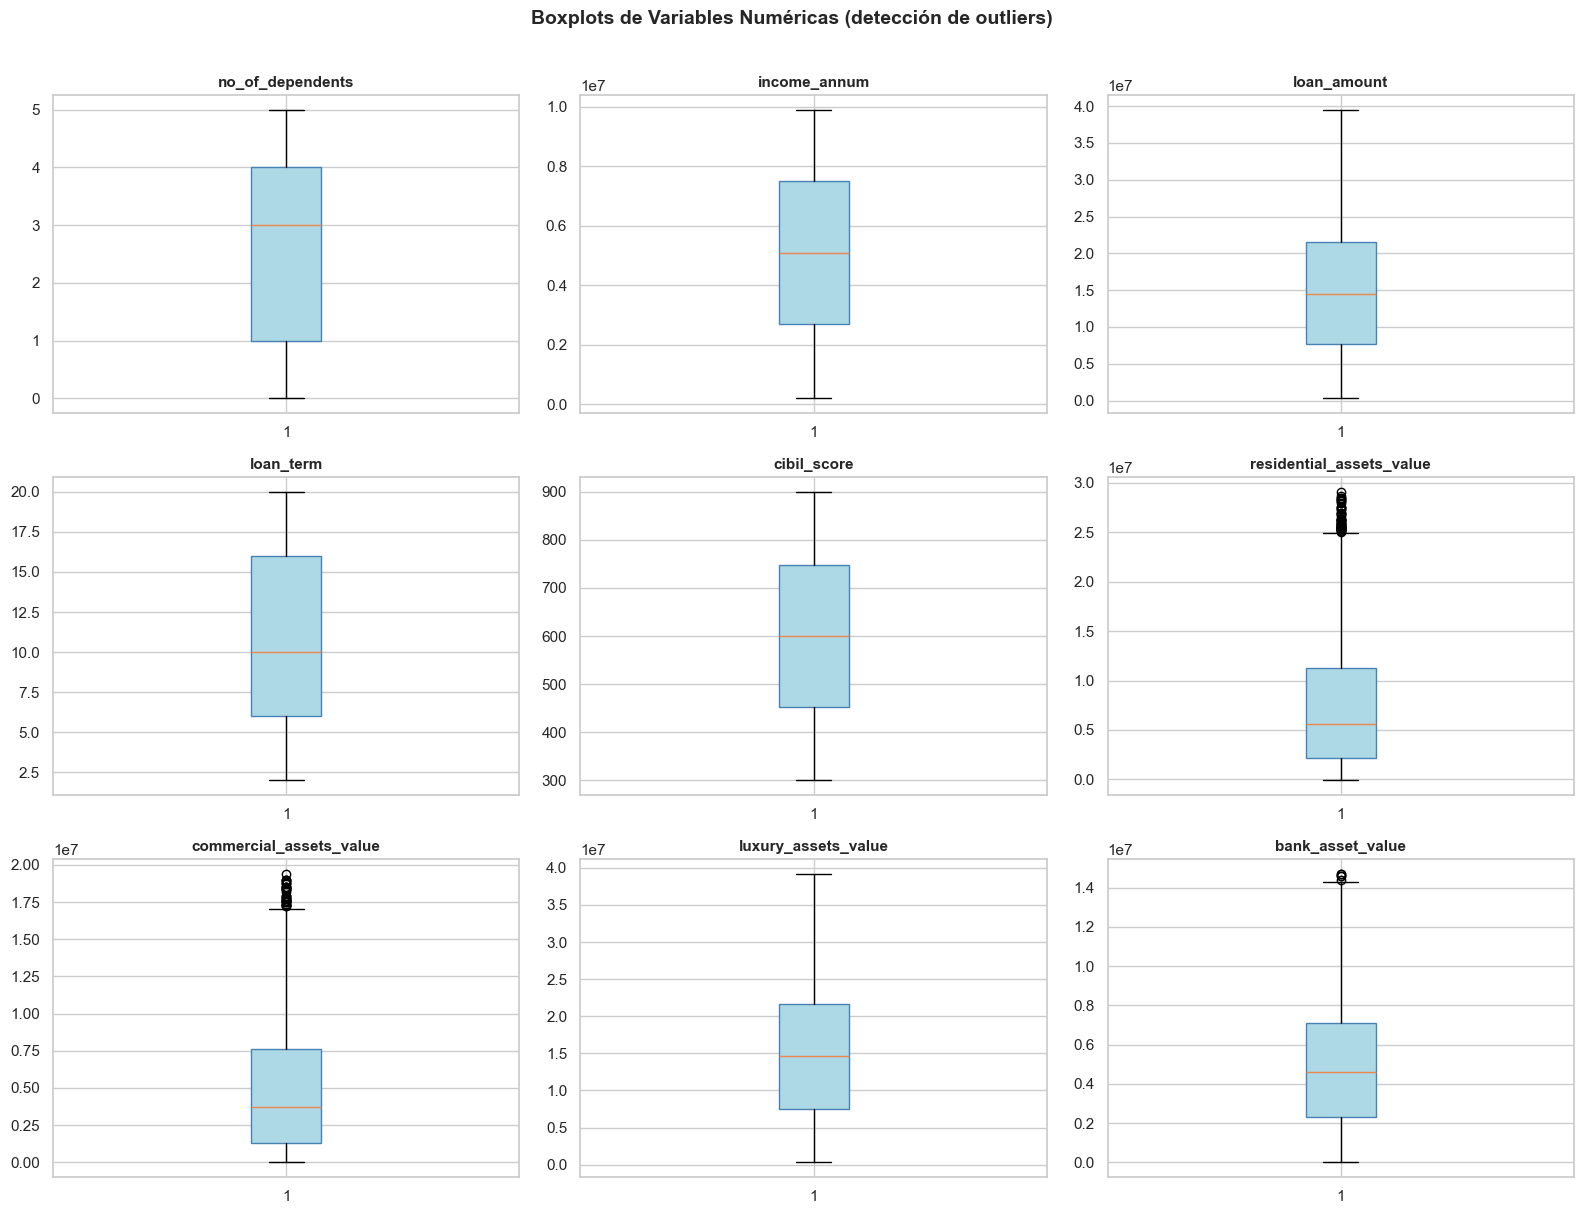

In [14]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'))
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Boxplots de Variables Numéricas (detección de outliers)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Estadísticas descriptivas extendidas
stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurt()
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
no_of_dependents,4269.0,2.50,1.70,0.0,1.0,3.0,4.0,5.0,-0.02,-1.26
income_annum,4269.0,5059123.92,2806839.83,200000.0,2700000.0,5100000.0,7500000.0,9900000.0,-0.01,-1.18
loan_amount,4269.0,15133450.46,9043362.98,300000.0,7700000.0,14500000.0,21500000.0,39500000.0,0.31,-0.74
loan_term,4269.0,10.90,5.71,2.0,6.0,10.0,16.0,20.0,0.04,-1.22
cibil_score,4269.0,599.94,172.43,300.0,453.0,600.0,748.0,900.0,-0.01,-1.19
residential_assets_value,4269.0,7472616.54,6503636.59,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0,0.98,0.18
commercial_assets_value,4269.0,4973155.31,4388966.09,0.0,1300000.0,3700000.0,7600000.0,19400000.0,0.96,0.10
luxury_assets_value,4269.0,15126305.93,9103753.67,300000.0,7500000.0,14600000.0,21700000.0,39200000.0,0.32,-0.74
bank_asset_value,4269.0,4976692.43,3250185.31,0.0,2300000.0,4600000.0,7100000.0,14700000.0,0.56,-0.40


### Observaciones – Variables Numéricas

- `cibil_score`: Distribuida entre ~300 y ~900. Es posiblemente la variable más predictiva del crédito 
- `income_annum` y `loan_amount`: Distribuciones aproximadamente uniformes en el rango disponible.
- `loan_term`: Variable discreta (entre 2 y 20 años). Puede tratarse como numérica o categórica.
- `no_of_dependents`: Baja variabilidad, rango 0-5.
- Variables de activos: Distribuciones sesgadas a la derecha, algunos con valores extremos. Se considerará transformación logarítmica en el pipeline.

### 5.2 Variables Categóricas

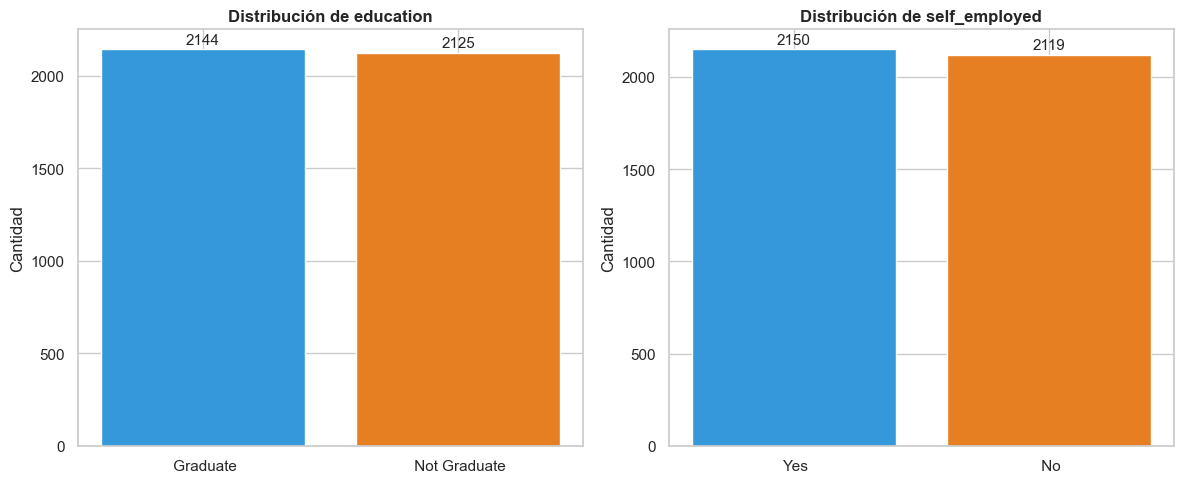


education:
education
Graduate        50.2%
Not Graduate    49.8%
Name: proportion, dtype: object

self_employed:
self_employed
Yes    50.4%
No     49.6%
Name: proportion, dtype: object


In [16]:
cat_cols = ['education', 'self_employed']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=['#3498db', '#e67e22'], edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cantidad')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                     str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts(normalize=True).map('{:.1%}'.format))

### Observaciones – Variables Categóricas

- **`education`**: Distribución casi equitativa entre *Graduate* y *Not Graduate* (~52% / ~48%).
- **`self_employed`**: La mayoría son empleados dependientes (~85% *No*).

## 6. Análisis Bivariado: Variables vs `loan_status`

### 6.1 `cibil_score` vs `loan_status` 


In [17]:
fig = px.histogram(
    df, x='cibil_score', color='loan_status',
    nbins=40, barmode='overlay', opacity=0.7,
    color_discrete_map={'Approved': '#2ecc71', 'Rejected': '#e74c3c'},
    title='Distribución del CIBIL Score por Estado del Crédito',
    labels={'cibil_score': 'CIBIL Score', 'loan_status': 'Estado'}
)
fig.show()

print('Estadísticas de cibil_score por loan_status:')
print(df.groupby('loan_status')['cibil_score'].describe().round(1))

Estadísticas de cibil_score por loan_status:
              count   mean    std    min    25%    50%    75%    max
loan_status                                                         
Approved     2656.0  703.5  125.2  300.0  618.0  711.0  803.0  900.0
Rejected     1613.0  429.5   78.4  300.0  364.0  429.0  493.0  885.0


### Observaciones – CIBIL Score

La distribución del CIBIL score muestra una separación entre aprobados y rechazados:
- **Aprobados** concentran puntajes en el rango 600–900 puntajes altos.
- **Rechazados** se agrupan en el rango 300–600 puntajes bajos.

El cibil_score es probablemente la variable más predictiva del modelo. Se observa una zona de intersección alrededor de 400-600 

### 6.2 Variables Numéricas vs `loan_status`

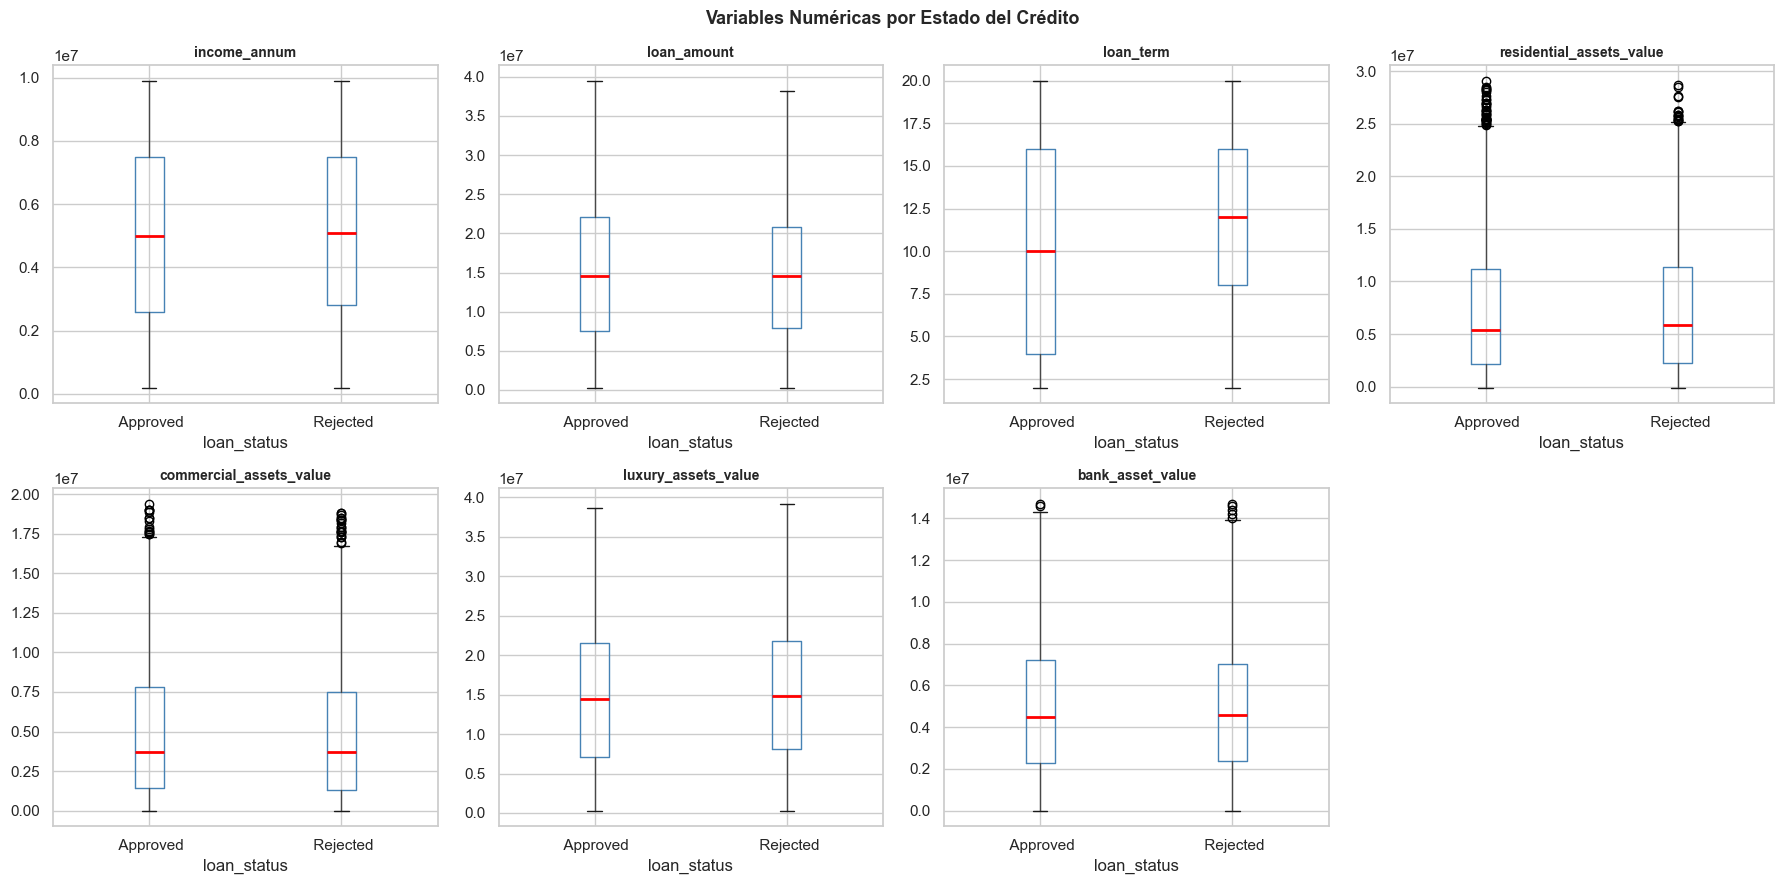

In [18]:
num_features = ['income_annum', 'loan_amount', 'loan_term',
                'residential_assets_value', 'commercial_assets_value',
                'luxury_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df.boxplot(column=col, by='loan_status', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('loan_status')
    axes[i].set_ylabel('')

# Ocultar último subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Variables Numéricas por Estado del Crédito', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Medias por grupo
print(' Medias por loan_status ')
df.groupby('loan_status')[num_features + ['cibil_score', 'no_of_dependents']].mean().round(0)

 Medias por loan_status 


,income_annum,loan_amount,loan_term,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,cibil_score,no_of_dependents
loan_status,,,,,,,,,
Approved,5025904.0,15247252.0,10.0,7399812.0,5001355.0,15016604.0,4959526.0,703.0,2.0
Rejected,5113825.0,14946063.0,12.0,7592498.0,4926720.0,15306944.0,5004960.0,429.0,3.0


### 6.3 Variables Categóricas vs `loan_status`

In [21]:
for col in ['education', 'self_employed']:
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    
    fig = px.bar(
        ct.reset_index().melt(id_vars=col, var_name='loan_status', value_name='Porcentaje'),
        x=col, y='Porcentaje', color='loan_status',
        barmode='group',
        color_discrete_map={'Approved': '#2ecc71', 'Rejected': '#e74c3c'},
        title=f'Tasa de Aprobación por {col}',
        labels={col: col, 'Porcentaje': 'Porcentaje (%)'}
    )
    fig.show()
    
    # Prueba Chi-cuadrado
    contingency = pd.crosstab(df[col], df['loan_status'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f'Chi-cuadrado {col}: chi2={chi2:.2f}, p-valor={p:.4f}, '
          + ('Significativo ' if p < 0.05 else 'No significativo '))

Chi-cuadrado education: chi2=0.08, p-valor=0.7720, No significativo 


Chi-cuadrado self_employed: chi2=0.00, p-valor=1.0000, No significativo 


### 6.4 `no_of_dependents` vs `loan_status`

In [22]:
dep_noshow = pd.crosstab(df['no_of_dependents'], df['loan_status'], normalize='index') * 100

fig = px.bar(
    dep_noshow.reset_index().melt(id_vars='no_of_dependents', var_name='loan_status', value_name='Porcentaje'),
    x='no_of_dependents', y='Porcentaje', color='loan_status',
    barmode='group',
    color_discrete_map={'Approved': '#2ecc71', 'Rejected': '#e74c3c'},
    title='Tasa de Aprobación por Número de Dependientes',
    labels={'no_of_dependents': 'N° de Dependientes', 'Porcentaje': 'Porcentaje (%)'}
)
fig.show()

print('Distribución de loan_status por no_of_dependents:')
print(dep_noshow.round(1))

Distribución de loan_status por no_of_dependents:
loan_status       Approved  Rejected
no_of_dependents                    
0                     64.2      35.8
1                     61.7      38.3
2                     62.3      37.7
3                     62.9      37.1
4                     61.8      38.2
5                     60.3      39.7


## 7. Matriz de Correlación

In [23]:
# Codificar target para incluir en correlación
df_corr = df.copy()
df_corr['loan_status_num'] = (df_corr['loan_status'] == 'Approved').astype(int)
df_corr['education_num'] = (df_corr['education'] == 'Graduate').astype(int)
df_corr['self_employed_num'] = (df_corr['self_employed'] == 'Yes').astype(int)

corr_cols = ['no_of_dependents', 'education_num', 'self_employed_num',
             'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
             'residential_assets_value', 'commercial_assets_value',
             'luxury_assets_value', 'bank_asset_value', 'loan_status_num']

corr_matrix = df_corr[corr_cols].corr()

fig = px.imshow(
    corr_matrix,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Matriz de Correlación',
    text_auto='.2f',
    aspect='auto'
)
fig.update_layout(height=600)
fig.show()

In [24]:
# Correlaciones con el target
target_corr = corr_matrix['loan_status_num'].drop('loan_status_num').sort_values(key=abs, ascending=False)
print('Correlación con loan_status_num (Approved=1):')
print(target_corr.round(3).to_string())

Correlación con loan_status_num (Approved=1):
no_of_dependents           NaN
education_num              NaN
self_employed_num          NaN
income_annum               NaN
loan_amount                NaN
loan_term                  NaN
cibil_score                NaN
residential_assets_value   NaN
commercial_assets_value    NaN
luxury_assets_value        NaN
bank_asset_value           NaN


### Observaciones – Correlaciones

- `cibil_score` tiene la correlación más alta con el target → confirma que es la variable más predictiva.
- Las variables de activos (`luxury_assets_value`, `commercial_assets_value`, etc..) muestran correlaciones positivas moderadas.
- `income_annum` y `loan_amount` tienen correlación positiva con aprobación — a mayor ingreso o monto solicitado, mayor probabilidad de aprobación dentro del perfil evaluado
- `education` y `self_employed` muestran correlaciones bajas.


## 8. Feature Engineering:

In [25]:
df_fe = df.copy()

# 1. Ratio préstamo / ingreso anual
df_fe['loan_to_income_ratio'] = df_fe['loan_amount'] / (df_fe['income_annum'] + 1)

# 2. Total de activos
df_fe['total_assets'] = (
    df_fe['residential_assets_value'].clip(lower=0) +
    df_fe['commercial_assets_value'] +
    df_fe['luxury_assets_value'] +
    df_fe['bank_asset_value']
)

# 3. Ratio préstamo / activos totales
df_fe['loan_to_assets_ratio'] = df_fe['loan_amount'] / (df_fe['total_assets'] + 1)

# 4. Indicador de activos altos
df_fe['high_assets'] = (df_fe['total_assets'] > df_fe['total_assets'].median()).astype(int)

new_features = ['loan_to_income_ratio', 'total_assets', 'loan_to_assets_ratio', 'high_assets']

print('Nuevas variables creadas:')
df_fe[new_features].describe().round(2)

Nuevas variables creadas:


,loan_to_income_ratio,total_assets,loan_to_assets_ratio,high_assets
count,4269.00,4269.00,4269.00,4269.0
mean,2.98,32549426.10,0.49,0.5
std,0.60,19505944.78,0.14,0.5
min,1.50,500000.00,0.18,0.0
25%,2.46,16300000.00,0.38,0.0
50%,3.00,31500000.00,0.47,0.0
75%,3.50,47200000.00,0.57,1.0
max,4.00,90700000.00,1.33,1.0


In [26]:
# Analizar nuevas variables vs target
for feat in ['loan_to_income_ratio', 'loan_to_assets_ratio']:
    fig = px.histogram(
        df_fe, x=feat, color='loan_status',
        nbins=40, barmode='overlay', opacity=0.7,
        color_discrete_map={'Approved': '#2ecc71', 'Rejected': '#e74c3c'},
        title=f'{feat} por Estado del Crédito'
    )
    fig.show()

print('\nEstadísticas de nuevas variables por loan_status:')
df_fe.groupby('loan_status')[['loan_to_income_ratio', 'total_assets', 'loan_to_assets_ratio']].mean().round(3)


Estadísticas de nuevas variables por loan_status:


,loan_to_income_ratio,total_assets,loan_to_assets_ratio
loan_status,,,
Approved,3.026,3.237790e+07,0.490
Rejected,2.918,3.283187e+07,0.481


### Observaciones – Feature Engineering



- `loan_to_income_ratio`: Relación entre el monto solicitado y el ingreso. Valores altos pueden indicar mayor riesgo de rechazo.
- `total_assets`: Suma de todos los activos del solicitante. Los aprobados tienden a tener mayor patrimonio total.
- `loan_to_assets_ratio`: Cuánto representa el préstamo respecto al total de activos. Indicador de riesgo financiero.



## 9. Análisis de Segmentos por CIBIL Score

In [ ]:
# Crear grupos de CIBIL score
df['cibil_group'] = pd.cut(
    df['cibil_score'],
    bins=[300, 450, 600, 700, 750, 900],
    labels=['300-450\n(Muy Bajo)', '450-600\n(Bajo)', '600-700\n(Regular)',
            '700-750\n(Bueno)', '750-900\n(Excelente)']
)

cibil_noshow = pd.crosstab(df['cibil_group'], df['loan_status'], normalize='index') *100

fig = px.bar(
    cibil_noshow.reset_index().melt(id_vars='cibil_group', var_name='loan_status', value_name='Porcentaje'),
    x='cibil_group', y='Porcentaje', color='loan_status',
    barmode='group',
    color_discrete_map={'Approved': '#2ecc71', 'Rejected': '#e74c3c'},
    title='Tasa de Aprobación por Grupo de CIBIL Score',
    labels={'cibil_group': 'Grupo CIBIL', 'Porcentaje': 'Porcentaje (%)'}
)
fig.show()

print('Tasa de aprobación por grupo CIBIL:')
print(cibil_noshow.round(1))

Tasa de aprobación por grupo CIBIL:
loan_status           Approved  Rejected
cibil_group                             
300-450\n(Muy Bajo)       10.8      89.2
450-600\n(Bajo)           39.0      61.0
600-700\n(Regular)        99.4       0.6
700-750\n(Bueno)          99.7       0.3
750-900\n(Excelente)      99.4       0.6


## 10. Conclusiones
### Hallazgos Principales

1. La Variable más predictiva es `cibil_score` ya que existe una separación entre aprobados (score alto) y rechazados (score bajo) y es la variable de mayor aporte al modelo.

2. El 62% Approved / 38% Rejected es de nivel moderado. Se usará `class_weight='balanced'` 

3. Respecto a la calidad de datos, el dataset es limpio (0 nulos, 0 duplicados). El único problema  son las 28 filas con `residential_assets_value` negativo que se corregirán a 0 en el preprocesamiento.

4. las variables categóricas `education` y `self_employed` tienen asociación significativa con el target (chi-cuadrado), aunque con efecto pequeño.

5.  Se crearán `loan_to_income_ratio`, `total_assets` y `loan_to_assets_ratio` como variables derivadas.

6.  `loan_id`  es un identificador sin valor predictivo. `cibil_group` creada solo para análisis.


